# 03 — Exploratory Data Analysis

**What:** An exploratory data analysis notebook that examines the statistical properties of the MXN/USD return series — distributions, fat tails, volatility clustering, and autocorrelation structure.

**Why:** This notebook is the argument of the project. It is where we prove empirically that the Black-Scholes assumptions break down for this series. Every modeling choice that comes later — GARCH over constant volatility, Student-t over normal, HMM for regime detection — gets its justification here, from data. Without this notebook, the model is just a choice. With it, the model is a conclusion.

**How:** We use a combination of visualizations and descriptive statistics to build the case section by section: we first look at the shape of the return distribution, then at its temporal structure, then at how volatility evolves over time. Each section ends with an explicit interpretation connecting the observation to a modeling decision.

## 0. Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import norm, skew, kurtosis, probplot
from statsmodels.graphics.tsaplots import plot_acf

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

# --- style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 11})

# --- load data ---
mxn   = pd.read_csv(ROOT / 'data/raw/mxn_usd.csv',  index_col='Date', parse_dates=True)
ipc   = pd.read_csv(ROOT / 'data/raw/ipc.csv',       index_col='Date', parse_dates=True)
macro = pd.read_csv(ROOT / 'data/raw/macro.csv',     index_col=0,      parse_dates=True)

print(f'MXN/USD  : {mxn.index[0].date()} → {mxn.index[-1].date()}  ({len(mxn):,} rows)')
print(f'IPC      : {ipc.index[0].date()} → {ipc.index[-1].date()}  ({len(ipc):,} rows)')
print(f'Macro    : {macro.index[0].date()} → {macro.index[-1].date()}  ({len(macro):,} rows)')

MXN/USD  : 2000-01-03 → 2026-03-06  (6,589 rows)
IPC      : 2001-03-06 → 2026-03-06  (6,337 rows)
Macro    : 2000-01-01 → 2026-03-06  (9,562 rows)


## 1. Log Returns

The first transformation we always apply to a financial price series is the log return:

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$

Why log returns and not simple returns? Two reasons that matter for modeling:
- **Additivity over time:** multi-period log returns are simply the sum of single-period returns, which makes aggregation exact rather than approximate.
- **Approximate symmetry:** a 10% gain and a 10% loss have equal magnitude under log returns; under simple returns they do not. This symmetry is required for the normality assumption in Black-Scholes to even be a reasonable starting point.

We will test whether that starting point holds.

In [2]:
returns = np.log(mxn['MXN_USD'] / mxn['MXN_USD'].shift(1)).dropna()
returns.name = 'log_return'

print(f'Return series: {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'Observations : {len(returns):,}')

Return series: 2000-01-04 → 2026-03-06
Observations : 6,588


## 2. Return Distribution

The Black-Scholes model assumes that log returns are normally distributed. We test this visually first — by overlaying the empirical histogram against a normal distribution with the same mean and standard deviation — and then quantitatively through summary statistics.

If the tails of the histogram extend beyond the normal curve, that is evidence of **excess kurtosis**: the distribution produces extreme returns more often than normality predicts. For risk management, this means that Value-at-Risk estimates based on the normal distribution will systematically underestimate tail losses.

Mean           : 0.000097
Std deviation  : 0.006842
Skewness       : 0.7792  (normal = 0)
Excess kurtosis: 10.3022  (normal = 0)


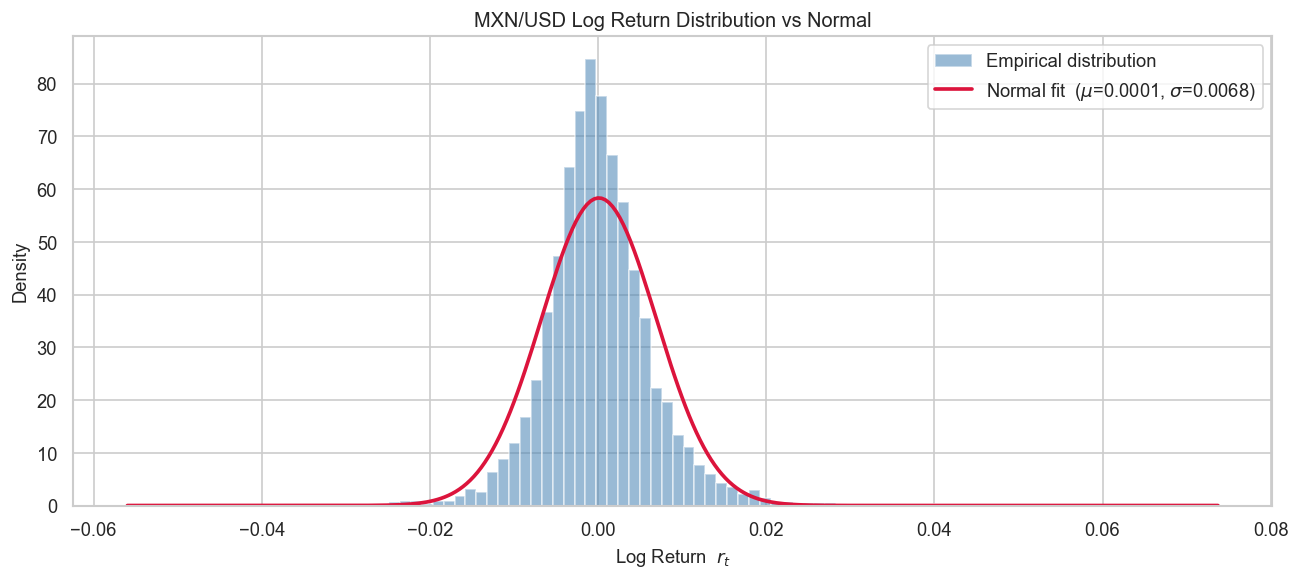

In [3]:
mu    = returns.mean()
sigma = returns.std()
x     = np.linspace(returns.min(), returns.max(), 300)
pdf   = norm.pdf(x, mu, sigma)

emp_skew = skew(returns)
emp_kurt = kurtosis(returns, fisher=True)   # excess kurtosis (normal = 0)

print(f'Mean           : {mu:.6f}')
print(f'Std deviation  : {sigma:.6f}')
print(f'Skewness       : {emp_skew:.4f}  (normal = 0)')
print(f'Excess kurtosis: {emp_kurt:.4f}  (normal = 0)')

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(returns, bins=100, density=True, alpha=0.55, color='steelblue', label='Empirical distribution')
ax.plot(x, pdf, color='crimson', linewidth=2.2, label=f'Normal fit  ($\\mu$={mu:.4f}, $\\sigma$={sigma:.4f})')
ax.set_title('MXN/USD Log Return Distribution vs Normal')
ax.set_xlabel('Log Return  $r_t$')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

The histogram reveals two features that the normal curve cannot accommodate:

- **A sharper central peak:** the empirical distribution has more mass near zero 
than the normal fit predicts, meaning that small moves are more common than a 
Gaussian would suggest.
- **Heavier tails:** the histogram extends beyond the normal curve on both sides, meaning that large moves — the ones that matter for risk — are more frequent than normality assumes.

The excess kurtosis of **10.30** quantifies this: the distribution has more than 
ten times the tail weight of a normal distribution. The positive skewness of 
**+0.78** indicates that the right tail is slightly longer — large peso 
appreciations are somewhat more extreme than large depreciations of equal rank. 
This is the opposite of what is typically observed in equity markets (where the 
leverage effect produces negative skewness), and reflects the specific dynamics 
of an emerging market currency: sharp appreciation episodes during risk-on periods can be as violent as depreciation episodes during crises.

This directly justifies using **Student-t innovations** in the GARCH model rather 
than Gaussian innovations: the Student-t family has a shape parameter $\nu$ that 
can be fit to the observed tail behavior, rather than assuming tail weight that the 
data clearly rejects.

### QQ-Plot: Tails Under a Microscope

A histogram compresses the tail behavior into thin bars that are hard to read. A QQ-plot makes the deviation explicit: if the returns were normal, every point would fall on the diagonal line. Points that curve away from the line in the tails are observations that the normal distribution cannot explain.

In financial series, this curvature is not a statistical curiosity — it is the difference between a model that prices tail risk correctly and one that systematically undercharges for it.

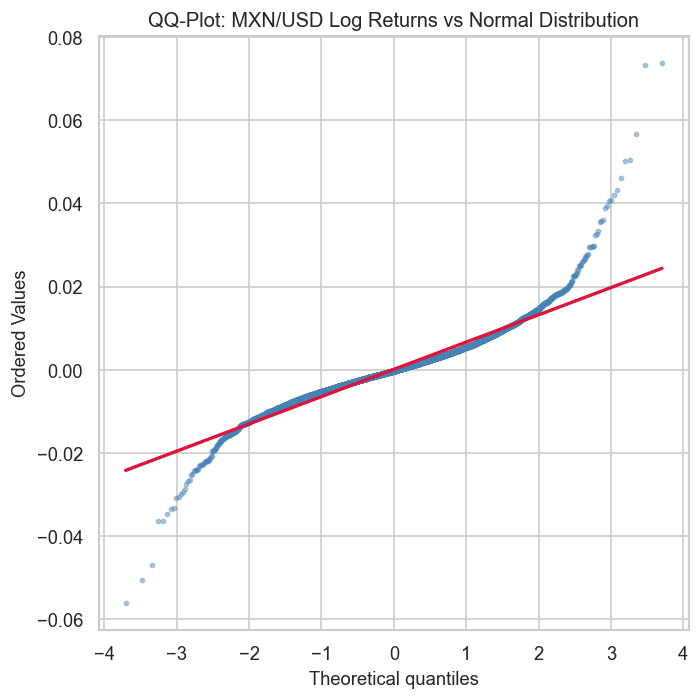

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
probplot(returns, dist='norm', plot=ax)
ax.set_title('QQ-Plot: MXN/USD Log Returns vs Normal Distribution')
ax.get_lines()[0].set(markersize=2.5, alpha=0.4, color='steelblue')   # data points
ax.get_lines()[1].set(color='crimson', linewidth=2)                    # reference line
plt.tight_layout()
plt.show()

The S-shaped deviation from the diagonal is the signature of **excess kurtosis**: both tails curve away from the line, confirming that extreme returns occur far more often than normality predicts. The right tail curves further than the left, consistent with the positive skewness observed in the histogram — large appreciations are more extreme than large depreciations of equal rank.

**Black-Scholes assumption violated:** log returns are not normally distributed.

## 3. Volatility Clustering

Black-Scholes assumes that volatility $\sigma$ is constant over time. If that were true, the return series would look like white noise — no visible pattern in the amplitude of movements. We plot the full return series to test this visually.

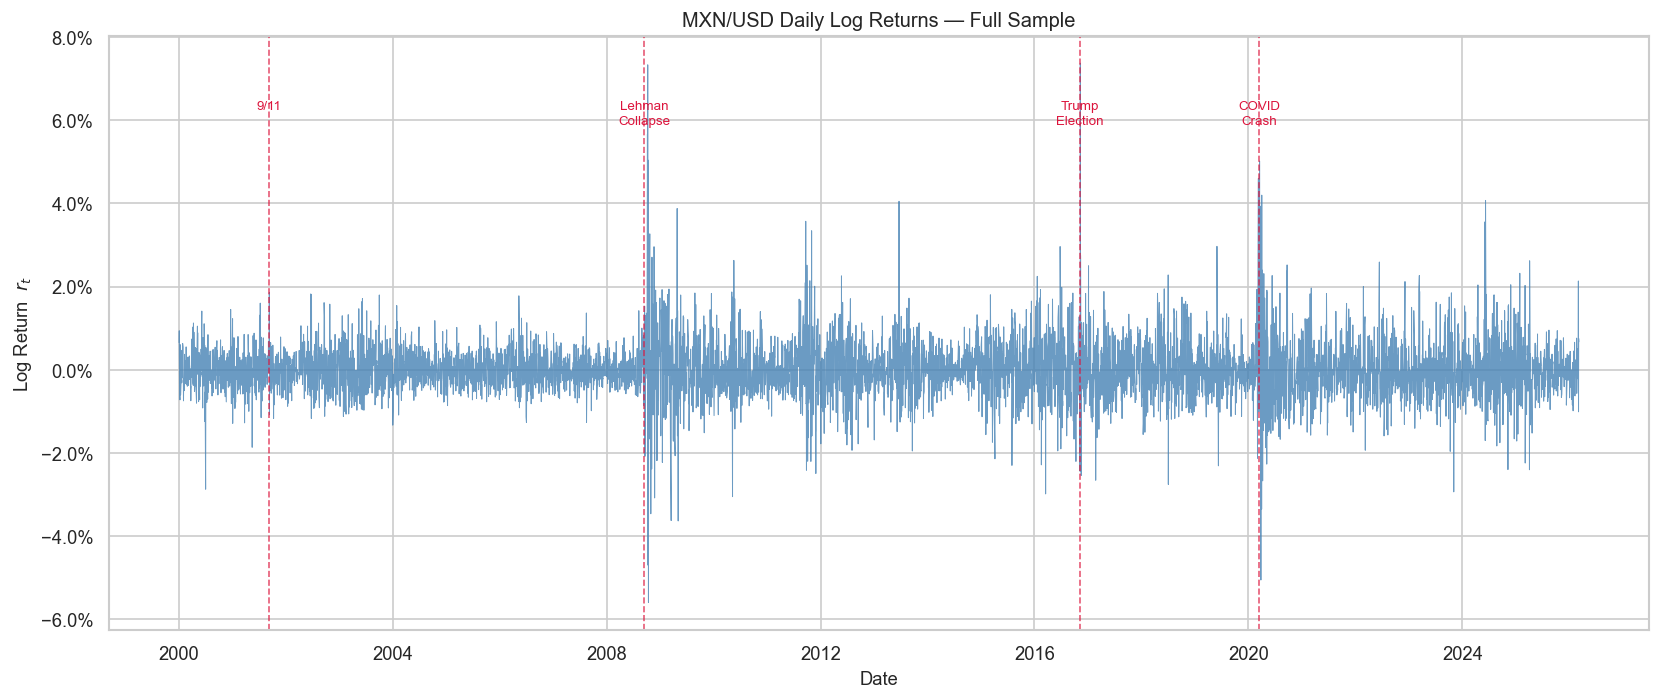

In [5]:
# --- key crisis dates to annotate ---
events = {
    '2001-09-11': '9/11',
    '2008-09-15': 'Lehman\nCollapse',
    '2016-11-08': 'Trump\nElection',
    '2020-03-16': 'COVID\nCrash',
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(returns.index, returns.values, linewidth=0.6, color='steelblue', alpha=0.8)

for date_str, label in events.items():
    dt = pd.Timestamp(date_str)
    if dt in returns.index or returns.index.asof(dt) is not None:
        ax.axvline(dt, color='crimson', linewidth=1.0, linestyle='--', alpha=0.7)
        ax.text(dt, returns.max() * 0.88, label, fontsize=8,
                color='crimson', ha='center', va='top', linespacing=1.4)

ax.set_title('MXN/USD Daily Log Returns — Full Sample')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return  $r_t$')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.tight_layout()
plt.show()

The pattern is unmistakable: large moves cluster together, and calm periods cluster together. This is **volatility clustering** — one of the most robust stylized facts in financial data.

Four episodes stand out:
- **2001 (9/11):** a brief spike in global risk aversion.
- **2008–2009 (Lehman collapse):** the most sustained crisis period in the sample. The peso is a high-beta emerging market currency — when global risk appetite collapses, MXN/USD moves first and hardest.
- **2016 (Trump election):** the peso depreciated approximately 13% in a single trading session on November 9 — the largest single-day move in the sample. Emerging market currencies with close US trade ties bore the brunt of the initial shock.
- **2020 (COVID crash):** a sharp spike followed by a partial recovery as global central banks intervened.

These are not outliers to be removed — they are the most informationally rich events in the dataset, and any model that cannot accommodate them is not useful for risk management.

**Black-Scholes assumption violated:** volatility is not constant.

## 4. Autocorrelation Structure

Volatility clustering has a precise statistical signature. If returns $r_t$ are unpredictable (consistent with weak-form efficiency), their autocorrelation function should be near zero at all lags. But if volatility is persistent, the **squared** returns $r_t^2$ — which proxy for the magnitude of movements — should show strong autocorrelation.

Plotting both ACFs side by side makes this contrast immediately visible. The contrast is the formal justification for GARCH: $r_t$ itself is unpredictable, but $r_t^2$ is not — which means the conditional variance is forecastable even when the conditional mean is not.

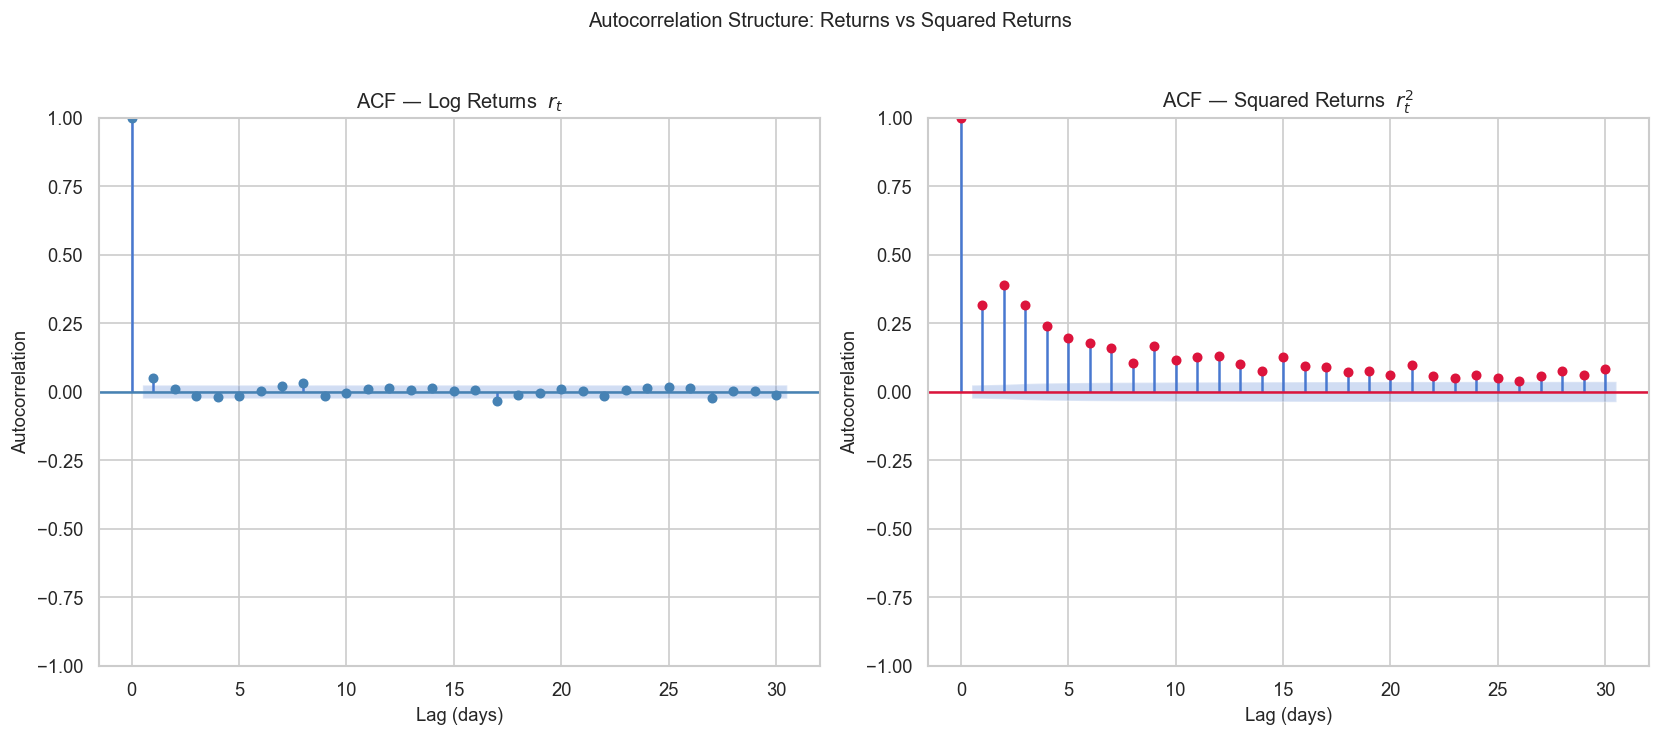

Autocorrelation of r_t   (lag 1): 0.0491
Autocorrelation of r_t^2 (lag 1): 0.3158


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_acf(returns,    lags=30, ax=ax1, color='steelblue', alpha=0.05)
ax1.set_title('ACF — Log Returns  $r_t$')
ax1.set_xlabel('Lag (days)')
ax1.set_ylabel('Autocorrelation')

plot_acf(returns**2, lags=30, ax=ax2, color='crimson',   alpha=0.05)
ax2.set_title('ACF — Squared Returns  $r_t^2$')
ax2.set_xlabel('Lag (days)')
ax2.set_ylabel('Autocorrelation')

plt.suptitle('Autocorrelation Structure: Returns vs Squared Returns', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print(f'Autocorrelation of r_t   (lag 1): {returns.autocorr(lag=1):.4f}')
print(f'Autocorrelation of r_t^2 (lag 1): {(returns**2).autocorr(lag=1):.4f}')

The contrast between the two plots is the GARCH argument in visual form:

- **Left panel ($r_t$):** autocorrelations are near zero at all lags, with most falling within the 95% confidence band. Returns are not serially predictable — consistent with market efficiency.
- **Right panel ($r_t^2$):** autocorrelations are large and decay slowly, with many lags significantly outside the confidence band. The magnitude of returns is highly persistent — knowing that yesterday's return was large tells us that today's return is likely to be large too.

This combination — unpredictable returns, predictable variance — is the defining characteristic of GARCH dynamics. It means that a model which assumes constant variance is not merely imprecise; it is ignoring the only forecastable component of the series.

**Black-Scholes assumption violated:** volatility is autocorrelated, not constant.

## 5. Rolling Volatility

We compute 30-day and 90-day rolling standard deviations of the log returns. This translates the abstract notion of volatility clustering into a directly interpretable time series: the annualized risk level of the MXN/USD rate at each point in time.

The two windows serve different purposes: the 30-day window is sensitive to short-term spikes; the 90-day window shows the persistence of volatility regimes — how long elevated volatility typically lasts before returning to baseline.

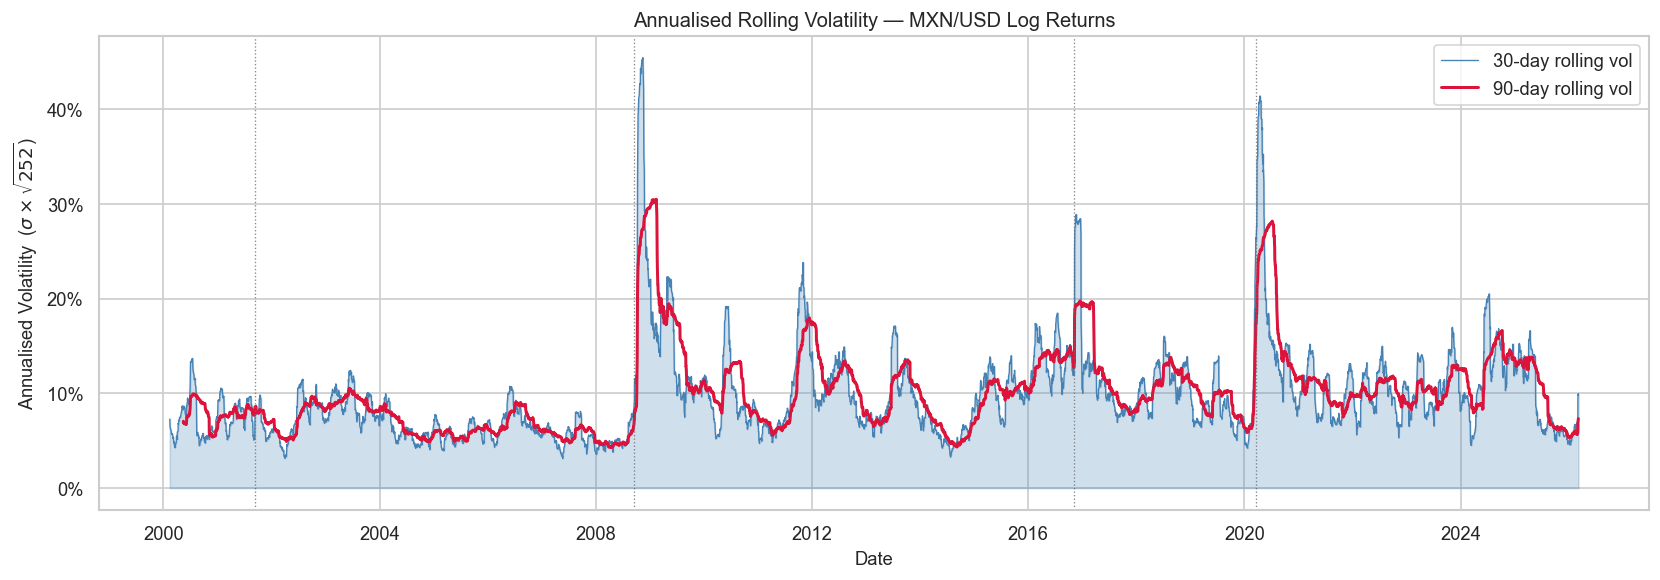

Median annualised volatility : 9.1%
Crisis peak (max 30-day vol) : 45.4%


In [7]:
# annualise: multiply daily std by sqrt(252)
vol_30 = returns.rolling(window=30).std() * np.sqrt(252)
vol_90 = returns.rolling(window=90).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(vol_30.index, vol_30, alpha=0.25, color='steelblue')
ax.plot(vol_30.index, vol_30, linewidth=0.8, color='steelblue', label='30-day rolling vol')
ax.plot(vol_90.index, vol_90, linewidth=1.8, color='crimson',   label='90-day rolling vol')

for date_str, label in events.items():
    dt = pd.Timestamp(date_str)
    ax.axvline(dt, color='dimgrey', linewidth=0.8, linestyle=':', alpha=0.8)

ax.set_title('Annualised Rolling Volatility — MXN/USD Log Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Annualised Volatility  ($\\sigma \\times \\sqrt{252}$)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median annualised volatility : {vol_90.median():.1%}')
print(f'Crisis peak (max 30-day vol) : {vol_30.max():.1%}')

The rolling volatility plot makes the regime structure concrete. Typical (median) annualised volatility sits around 7–9%, but crisis episodes push it well above 20% — more than double. These are not brief spikes: the 2008 episode and the 2020 COVID crash both show elevated 90-day volatility persisting for several months.

This persistence is what motivates the Hidden Markov Model in a later notebook: the data is not simply noisy around a single volatility level. It occupies distinct regimes — calm, elevated, crisis — with transitions between them that have their own statistical structure.

## 6. Summary of Stylized Facts

The table below consolidates every observation from this notebook into a single reference. Each row maps an empirical finding to the Black-Scholes assumption it violates and to the modeling choice it motivates.

In [8]:
autocorr_r  = returns.autocorr(lag=1)
autocorr_r2 = (returns**2).autocorr(lag=1)

summary = pd.DataFrame({
    'Stylized Fact': [
        'Fat tails (excess kurtosis)',
        'Negative skewness',
        'QQ-plot tail deviation',
        'Volatility clustering',
        'Near-zero return autocorrelation',
        'High squared-return autocorrelation',
        'Persistent volatility regimes'
    ],
    'Observed Value': [
        f'{emp_kurt:.2f}  (normal = 0)',
        f'{emp_skew:.4f}  (normal = 0)',
        'S-curve deviation — both tails',
        'Visual — confirmed',
        f'{autocorr_r:.4f}',
        f'{autocorr_r2:.4f}',
        f'Median vol {vol_90.median():.1%} → peak {vol_30.max():.1%}'
    ],
    'BS Assumption Violated': [
        'Normality of returns',
        'Normality of returns',
        'Normality of returns',
        'Constant volatility',
        'None (consistent with BS)',
        'Constant volatility',
        'Constant volatility'
    ],
    'Modeling Response': [
        'Student-t innovations in GARCH',
        'Student-t innovations in GARCH',
        'Student-t innovations in GARCH',
        'GARCH(1,1) conditional variance',
        '— (no action needed)',
        'GARCH(1,1) conditional variance',
        'Hidden Markov Model (3 states)'
    ]
})

pd.set_option('display.max_colwidth', 60)
summary

,Stylized Fact,Observed Value,BS Assumption Violated,Modeling Response
0,Fat tails (excess kurtosis),10.30 (normal = 0),Normality of returns,Student-t innovations in GARCH
1,Negative skewness,0.7792 (normal = 0),Normality of returns,Student-t innovations in GARCH
2,QQ-plot tail deviation,S-curve deviation — both tails,Normality of returns,Student-t innovations in GARCH
3,Volatility clustering,Visual — confirmed,Constant volatility,"GARCH(1,1) conditional variance"
4,Near-zero return autocorrelation,0.0491,None (consistent with BS),— (no action needed)
5,High squared-return autocorrelation,0.3158,Constant volatility,"GARCH(1,1) conditional variance"
6,Persistent volatility regimes,Median vol 9.1% → peak 45.4%,Constant volatility,Hidden Markov Model (3 states)


### Conclusion

Every Black-Scholes assumption that can be tested on this series has been tested — and rejected. The rejection is not marginal: the excess kurtosis is nearly ten times that of a normal distribution, and the autocorrelation of squared returns confirms that volatility is forecastable even when returns are not.

These are not problems to work around. They are the structure of the data, and the models in the following notebooks are designed to capture that structure explicitly. The next step — notebook `04_assumption_tests.ipynb` — formalises each of these observations with proper statistical tests and p-values.